# ENTRENANDO MODELO DE ML PARA PREDECIR LAS VENTAS DE ECOMMERCE
## DATASET: https://www.kaggle.com/datasets/algozee/multi-source-data-for-e-commerce-sales-prediction/data

#1. Importamos las librerias

In [120]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [121]:
sns.set(style='whitegrid',context='notebook')

#2. Cargar Dataset Limpio

In [122]:
df = pd.read_csv('/content/ecommerce_cleaned.csv')
df.head()

,order_datetime,year,month,week_of_year,day_of_week,order_hour,is_weekend,country,country_code,product_id,customer_id,unit_price_gbp,quantity_sold,sales_amount_gbp,population_total,gdp_current_usd,gdp_growth_pct,inflation_consumer_pct
0,2009-12-01 09:06:00,2009,12,49,1,9,0,United Kingdom,GBR,82582,13078,2.10,12,25.20,62276270.0,2.412840e+12,-17.633976,1.897090
1,2009-12-01 09:06:00,2009,12,49,1,9,0,United Kingdom,GBR,21756,13078,5.95,3,17.85,62276270.0,2.412840e+12,-17.633976,1.897090
2,2009-12-01 09:28:00,2009,12,49,1,9,0,France,FRA,21731,12682,1.65,24,39.60,64706436.0,2.700887e+12,-7.829100,0.105961
3,2009-12-01 09:28:00,2009,12,49,1,9,0,France,FRA,85014B,12682,5.95,3,17.85,64706436.0,2.700887e+12,-7.829100,0.105961
4,2009-12-01 09:28:00,2009,12,49,1,9,0,France,FRA,16161P,12682,0.42,25,10.50,64706436.0,2.700887e+12,-7.829100,0.105961


In [123]:
df.dtypes

,0
order_datetime,object
year,int64
month,int64
week_of_year,int64
day_of_week,int64
order_hour,int64
is_weekend,int64
country,object
country_code,object
product_id,object


#3. Preprocesamiento Numérico

In [124]:
df.describe()

,year,month,week_of_year,day_of_week,order_hour,is_weekend,customer_id,unit_price_gbp,quantity_sold,sales_amount_gbp,population_total,gdp_current_usd,gdp_growth_pct,inflation_consumer_pct
count,79905.000000,79905.000000,79905.000000,79905.000000,79905.000000,79905.000000,79905.000000,79905.000000,79905.000000,79905.000000,7.990500e+04,7.990500e+04,79905.000000,79905.000000
mean,2009.928640,7.382742,29.945172,2.606257,12.738665,0.161654,14824.711783,2.259798,7.794656,12.610997,5.563539e+07,2.216551e+12,0.554718,1.163874
std,0.257426,3.460935,15.018457,1.944811,2.326371,0.368136,1817.668576,1.600308,6.638224,8.786923,2.578589e+07,1.089330e+12,6.066129,1.620314
min,2009.000000,1.000000,1.000000,0.000000,7.000000,0.000000,12346.000000,0.001000,1.000000,0.001000,3.180410e+05,9.035824e+09,-19.629870,-15.182980
25%,2010.000000,4.000000,17.000000,1.000000,11.000000,0.000000,12979.000000,1.250000,2.000000,5.040000,6.276636e+07,2.485483e+12,-0.693878,1.089446
50%,2010.000000,8.000000,33.000000,2.000000,13.000000,0.000000,14713.000000,1.650000,6.000000,12.500000,6.276636e+07,2.485483e+12,3.010668,1.589081
75%,2010.000000,11.000000,44.000000,4.000000,14.000000,0.000000,16399.000000,2.950000,12.000000,17.700000,6.276636e+07,2.485483e+12,3.010668,1.589081
max,2010.000000,12.000000,52.000000,6.000000,20.000000,1.000000,18287.000000,7.500000,27.000000,40.950000,3.093782e+08,1.504897e+13,32.504047,16.527886


#Corregir Formato de Fechas

In [125]:
# convertir a fecha
df['order_datetime'] = pd.to_datetime(df['order_datetime'])

#Eliminacion de Variables MACRO y OTRAS
###Se eliminaron variables macroeconómicas como el PIB y la población, ya que el análisis se centra en el comportamiento de ventas a nivel transaccional, donde dichas variables no aportan información significativa y podrían introducir ruido en el modelo.

In [126]:
# Eliminamos variables macro y derivadas de fecha
df_model = df.drop(columns=[
    'year', 'week_of_year', 'gdp_current_usd', 'population_total',
    'gdp_growth_pct', 'inflation_consumer_pct', 'order_datetime', 'customer_id'
])
df_model.head()


,month,day_of_week,order_hour,is_weekend,country,country_code,product_id,unit_price_gbp,quantity_sold,sales_amount_gbp
0,12,1,9,0,United Kingdom,GBR,82582,2.10,12,25.20
1,12,1,9,0,United Kingdom,GBR,21756,5.95,3,17.85
2,12,1,9,0,France,FRA,21731,1.65,24,39.60
3,12,1,9,0,France,FRA,85014B,5.95,3,17.85
4,12,1,9,0,France,FRA,16161P,0.42,25,10.50


#4. Codificación de variables categóricas   

In [127]:
categorical_columns = df_model.select_dtypes(object).columns
categorical_columns

Index(['country', 'country_code', 'product_id'], dtype='object')

In [128]:
#Retirar columnas innecesarias para el modelo
df_model = df_model.drop(columns=['country_code', 'product_id'])
df_model

,month,day_of_week,order_hour,is_weekend,country,unit_price_gbp,quantity_sold,sales_amount_gbp
0,12,1,9,0,United Kingdom,2.10,12,25.20
1,12,1,9,0,United Kingdom,5.95,3,17.85
2,12,1,9,0,France,1.65,24,39.60
3,12,1,9,0,France,5.95,3,17.85
4,12,1,9,0,France,0.42,25,10.50
...,...,...,...,...,...,...,...,...
79900,12,3,20,0,United Kingdom,3.75,1,3.75
79901,12,3,20,0,United Kingdom,1.95,2,3.90
79902,12,3,20,0,United Kingdom,0.95,1,0.95
79903,12,3,20,0,United Kingdom,1.95,4,7.80


In [129]:
df_model.country.unique()

array(['United Kingdom', 'France', 'Australia', 'Ireland', 'Germany',
       'Portugal', 'Poland', 'Netherlands', 'Spain', 'Cyprus', 'Belgium',
       'Greece', 'Norway', 'Austria', 'United Arab Emirates', 'Denmark',
       'Italy', 'Switzerland', 'Sweden', 'United States', 'Japan',
       'Finland', 'Malta', 'South Africa', 'Singapore', 'Bahrain',
       'Israel', 'Thailand', 'Lithuania', 'Nigeria', 'Korea, Rep.',
       'Brazil', 'Canada', 'Iceland'], dtype=object)

In [130]:
df_model.columns

Index(['month', 'day_of_week', 'order_hour', 'is_weekend', 'country',
       'unit_price_gbp', 'quantity_sold', 'sales_amount_gbp'],
      dtype='object')

#Seleccion de columnas para el Modelo

In [131]:
df_model = df_model[['sales_amount_gbp', 'quantity_sold',
                     'country', 'month', 'day_of_week',
                     'order_hour', 'is_weekend']]
print("Columnas para el modelo:")
print(df_model.columns.tolist())

Columnas para el modelo:
['sales_amount_gbp', 'quantity_sold', 'country', 'month', 'day_of_week', 'order_hour', 'is_weekend']


###Escalamos el target "Sales"

In [132]:
# En lugar de esto:
#df_model['sales_amount_gbp'] = df_model['sales_amount_gbp'] / 1000
#print("Target 'sales_amount_gbp' escalado a miles de GBP")

df_model['sales_amount_gbp'] = np.log1p(df_model['sales_amount_gbp'])
print("Target transformado con log1p")



Target transformado con log1p


/tmp/ipython-input-2093830421.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['sales_amount_gbp'] = np.log1p(df_model['sales_amount_gbp'])


##Definir columnas Ordinales y One Hot encoding

##One-hot encoding de country con Scikit-Learn

In [133]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
#ordinal_cols = []
numeric_cols = ['quantity_sold', 'month', 'day_of_week', 'order_hour', 'is_weekend']
# Solo 'country' es categórica
onehot_cols = ['country']

#print("Ordinal columns:", ordinal_cols)
print(numeric_cols)
print("One-Hot columns:", onehot_cols)

['quantity_sold', 'month', 'day_of_week', 'order_hour', 'is_weekend']
One-Hot columns: ['country']


##Transformer

In [134]:
transformer = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), onehot_cols),
        # No incluimos OrdinalEncoder porque ordinal_cols está vacío
    ],
    remainder='passthrough',  # Todas las columnas numéricas se dejan sin cambios
    verbose_feature_names_out=False
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehot',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['country'])],
                  verbose_feature_names_out=False)

##Aplicamos el transformer al dataset

In [135]:
 ##Identificamos variable X y Y
 #Target -> X
X = df_model.drop(columns=['sales_amount_gbp'])
y = df_model['sales_amount_gbp']

In [136]:
data_transformed = transformer.fit_transform(X)

In [137]:
# Convertir a DataFrame con nombres limpios
data_transformed_df = pd.DataFrame(
    data_transformed,
    columns=transformer.get_feature_names_out(),
    index=X.index
)
data_transformed_df

,country_Austria,country_Bahrain,country_Belgium,country_Brazil,country_Canada,country_Cyprus,country_Denmark,country_Finland,country_France,country_Germany,...,country_Switzerland,country_Thailand,country_United Arab Emirates,country_United Kingdom,country_United States,quantity_sold,month,day_of_week,order_hour,is_weekend
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,12.0,12.0,1.0,9.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,3.0,12.0,1.0,9.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,24.0,12.0,1.0,9.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,12.0,1.0,9.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,25.0,12.0,1.0,9.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79900,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,12.0,3.0,20.0,0.0
79901,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,2.0,12.0,3.0,20.0,0.0
79902,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,12.0,3.0,20.0,0.0
79903,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,4.0,12.0,3.0,20.0,0.0


In [138]:
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("onehot__", "").replace("remainder__", "")
)
data_transformed_df.columns

Index(['country_Austria', 'country_Bahrain', 'country_Belgium',
       'country_Brazil', 'country_Canada', 'country_Cyprus', 'country_Denmark',
       'country_Finland', 'country_France', 'country_Germany',
       'country_Greece', 'country_Iceland', 'country_Ireland',
       'country_Israel', 'country_Italy', 'country_Japan',
       'country_Korea, Rep.', 'country_Lithuania', 'country_Malta',
       'country_Netherlands', 'country_Nigeria', 'country_Norway',
       'country_Poland', 'country_Portugal', 'country_Singapore',
       'country_South Africa', 'country_Spain', 'country_Sweden',
       'country_Switzerland', 'country_Thailand',
       'country_United Arab Emirates', 'country_United Kingdom',
       'country_United States', 'quantity_sold', 'month', 'day_of_week',
       'order_hour', 'is_weekend'],
      dtype='object')

###Guardamos dataset transformado

In [139]:
data_transformed_df.to_csv('ecommerce_transformed.csv', index=False)
print("Dataset transformado guardado como 'ecommerce_transformed.csv'")

Dataset transformado guardado como 'ecommerce_transformed.csv'


#5. Correlaciones

In [140]:
data_transformed_df = pd.read_csv('/content/ecommerce_transformed.csv')
data_transformed_df

,country_Austria,country_Bahrain,country_Belgium,country_Brazil,country_Canada,country_Cyprus,country_Denmark,country_Finland,country_France,country_Germany,...,country_Switzerland,country_Thailand,country_United Arab Emirates,country_United Kingdom,country_United States,quantity_sold,month,day_of_week,order_hour,is_weekend
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,12.0,12.0,1.0,9.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,3.0,12.0,1.0,9.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,24.0,12.0,1.0,9.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,12.0,1.0,9.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,25.0,12.0,1.0,9.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79900,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,12.0,3.0,20.0,0.0
79901,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,2.0,12.0,3.0,20.0,0.0
79902,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,12.0,3.0,20.0,0.0
79903,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,4.0,12.0,3.0,20.0,0.0


In [141]:
# Calculamos la matriz de correlaciones solo de las features
data_transformed_df['sales_amount_gbp'] = y.values
corr_matrix = data_transformed_df.corr()

# Calculamos la correlación de cada feature con el target (y)
corr_target = corr_matrix['sales_amount_gbp'].sort_values(ascending=False)
corr_target

,sales_amount_gbp
sales_amount_gbp,1.000000
quantity_sold,0.537908
country_Ireland,0.179923
country_Germany,0.165337
country_France,0.100011
country_Switzerland,0.068013
country_Belgium,0.062986
country_Portugal,0.051989
country_Sweden,0.046351
country_Norway,0.039342


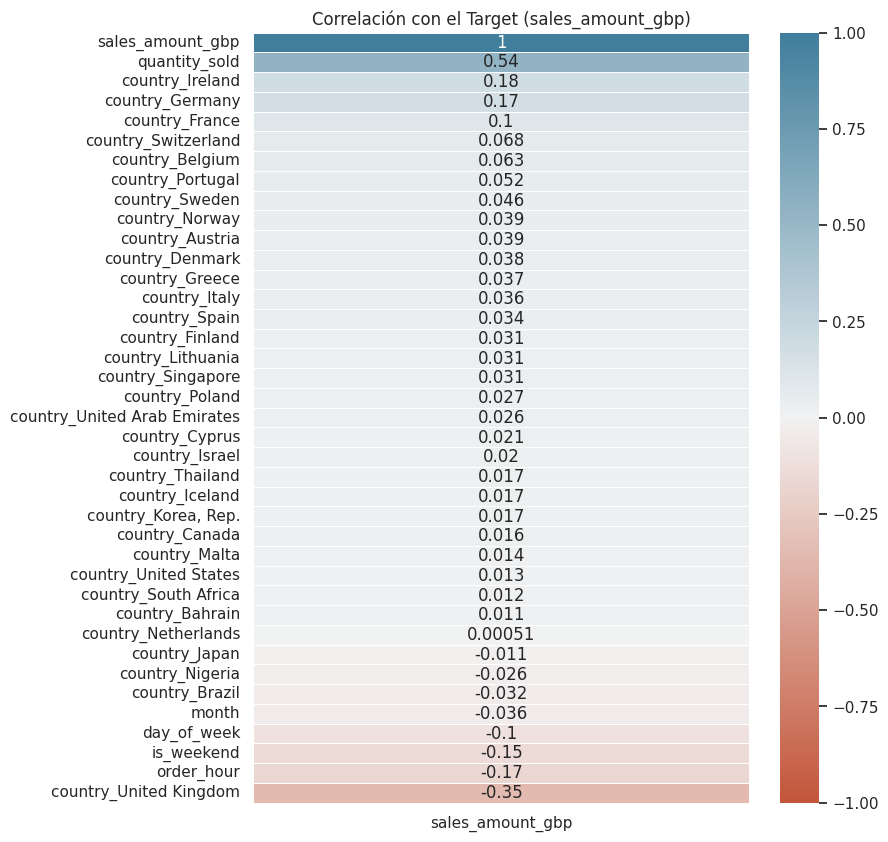

In [142]:
# Heatmap
plt.figure(figsize=(8, 10))
sns.heatmap(
    corr_target.to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    linewidths=0.5
)
plt.title('Correlación con el Target (sales_amount_gbp)')
plt.show()

# Train
##Identificamos variable X y Y , dividimos en train test

In [143]:
cols = corr_target.index.tolist()

In [144]:
# eliminar target
if 'sales_amount_gbp' in cols:
    cols.remove('sales_amount_gbp')

In [145]:
X = data_transformed_df[cols].values
y = data_transformed_df['sales_amount_gbp'].values.reshape(-1, 1)

In [146]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (55933, 38)
Test shape: (23972, 38)


#ESCALAMIENTO DE DATOS

In [147]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

#Comparación de Modelos

In [148]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error



#Diccionario de Modelos
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=0.1),
    "Ridge": Ridge(alpha=1.0),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=15),
    "SVR": SVR(kernel='rbf', C=1.0, epsilon=0.1),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=150,
        max_depth=7,              # Reducimos profundidad para evitar overfitting
        min_samples_split=8,
        min_samples_leaf=3,
        random_state=42
    )
}

## CREAMOS BUCLE PARA PROBAR CADA MODELO DEL DICCIONARIO

In [149]:
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train_scaled.ravel())
    y_pred_scaled = model.predict(X_test_scaled)


    r2 = r2_score(y_test_scaled, y_pred_scaled)
    mse = mean_squared_error(y_test_scaled, y_pred_scaled)
    mae = mean_absolute_error(y_test_scaled, y_pred_scaled)

    results[name] = {"R2": round(r2, 4),
                     "MSE": round(mse, 4),
                     "MAE": round(mae, 4)}

results_df = pd.DataFrame(results).T
display(results_df)

,R2,MSE,MAE
Linear Regression,0.3533,0.6573,0.6702
Lasso,0.3177,0.6935,0.6972
Ridge,0.3533,0.6573,0.6702
KNN Regressor,0.6000,0.4066,0.5042
SVR,0.5550,0.4523,0.5305
Random Forest Regressor,0.6257,0.3805,0.4859


##BUSCAMOS EL MEJOR MODELO

In [150]:
best_model_name = results_df['R2'].idxmax()

print(f"\n✅ Mejor modelo según R²: {best_model_name} (R2 = {results_df.loc[best_model_name, 'R2']:.4f})")
print(f"   MSE = {results_df.loc[best_model_name, 'MSE']:.4f}")
print(f"   MAE = {results_df.loc[best_model_name, 'MAE']:.4f}")



✅ Mejor modelo según R²: Random Forest Regressor (R2 = 0.6257)
   MSE = 0.3805
   MAE = 0.4859


##GRAFICOS DE COMPARACIÓN

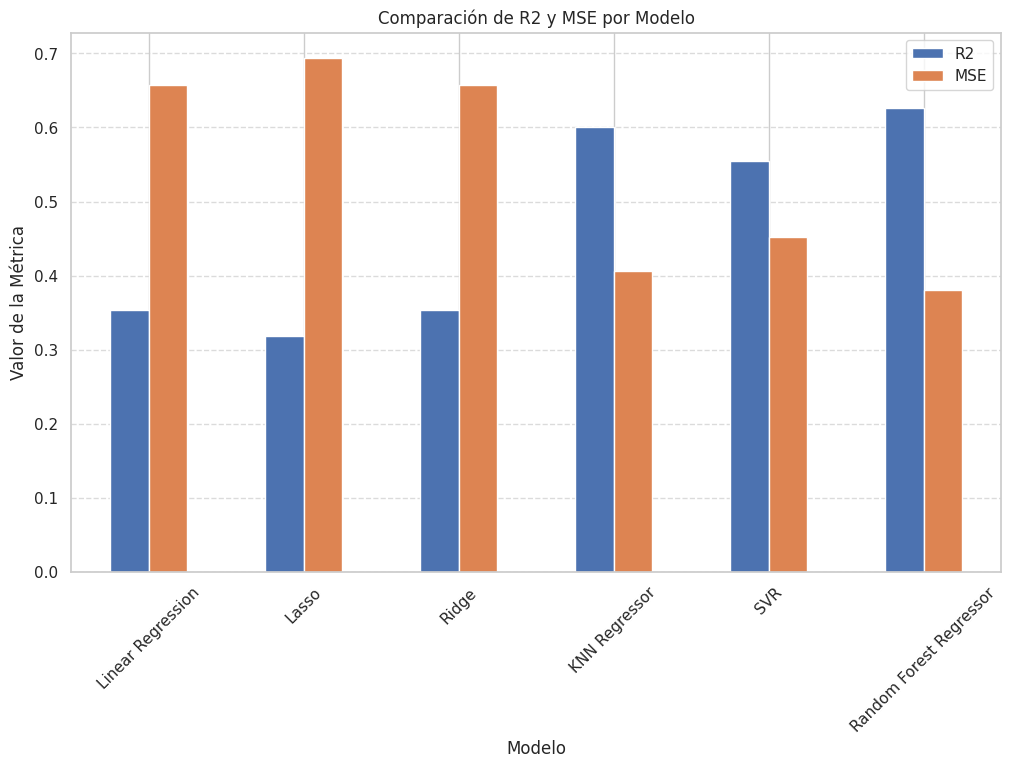

In [151]:
import matplotlib.pyplot as plt

results_to_plot = results_df[['R2', 'MSE']]

fig, ax = plt.subplots(figsize=(12, 7))
results_to_plot.plot(kind='bar', ax=ax)

plt.title('Comparación de R2 y MSE por Modelo')
plt.ylabel('Valor de la Métrica')
plt.xlabel('Modelo')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

##GUARDAMOS EL MEJOR MODELO Y SUS SCALERS

In [152]:
import joblib
#Obtener el mejor modelo
best_model = models[best_model_name]
#Guardar el mejor modelo
joblib.dump(best_model, 'model.pkl')

#Guardar los scalers
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')
joblib.dump(transformer, 'transformer.pkl')

print("Modelo, scalers y transformer guardados")

Modelo, scalers y transformer guardados


##CARGAMOS EL MODELO Y SUS SCALERS

In [153]:
#Cargamos
model = joblib.load('model.pkl')
scaler_X = joblib.load('scaler_X.pkl')
scaler_y = joblib.load('scaler_y.pkl')
transformer = joblib.load('transformer.pkl')

print("Modelo cargado correctamente")

Modelo cargado correctamente


##FUNCIÓN DE PREDICCIÓN

In [154]:
def predict_sales(
    country_input,
    quantity_sold,
    month,
    day_of_week,
    order_hour,
    is_weekend
):


#Predecir Ventas en GBP (dehaciedo el log1p)
#Crear input en formato DataFrame (IMPORTANTE para transformer)
  new_data = pd.DataFrame([{
        'country': country_input,
        'quantity_sold': quantity_sold,
        'month': month,
        'day_of_week': day_of_week,
        'order_hour': order_hour,
        'is_weekend': is_weekend
    }])
  #Transformación (OneHot + passthrough)
  X_transformed = transformer.transform(new_data)

  #Escalado de features
  X_scaled = scaler_X.transform(X_transformed)

    # 3. Predicción (sale en escala log)
  pred_scaled = model.predict(X_scaled)

    # 4. Invertir scaler del target
  pred_log = scaler_y.inverse_transform(
        pred_scaled.reshape(-1, 1)
    )[0][0]

    # 5. Invertir log1p → valor real
  pred_final = np.expm1(pred_log)

  return round(pred_final, 2)

  '''
    # One-hot manual de country
    countries = transformer.named_transformers_['onehot'].categories_[0][1:]
    country_encoded = [0.0] * len(countries)

    if country_input in countries:
        idx = list(countries).index(country_input)
        country_encoded[idx] = 1.0
     # Crear input
    new_data = np.array([[
        *country_encoded,
        quantity_sold,
        month,
        day_of_week,
        order_hour,
        is_weekend
    ]])

    # Escalar
    new_data_scaled = scaler_X.transform(new_data)

    # Predecir
    prediction_scaled = model.predict(new_data_scaled)

    # Inversa del escalado
    prediction_log = scaler_y.inverse_transform(prediction_scaled.reshape(-1, 1))[0][0]

    # Invertir el log
    prediction_final = np.expm1(prediction_log)

    return prediction_final
    '''

In [155]:
#prueba
pred = predict_sales(
    country_input='France',
    quantity_sold=17,
    month=12,
    day_of_week=1,
    order_hour=9,
    is_weekend=0
)

print(f"Predicción de ventas: {pred:.2f} GBP")

Predicción de ventas: 2.67 GBP
